In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ushape.csv")

In [4]:
df.columns = ["X","Y","CLASS"]

In [5]:
df.head()

,X,Y,CLASS
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [6]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]

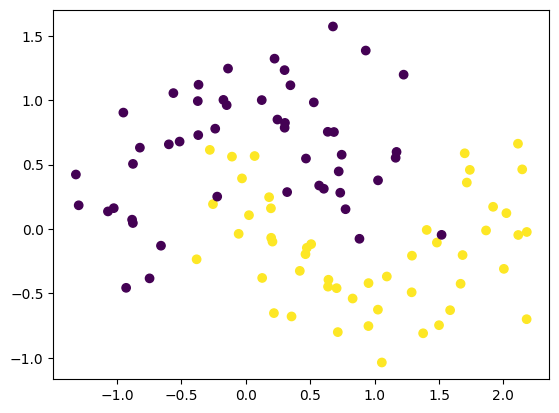

In [7]:
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=y)
#

In [9]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from keras import initializers

In [17]:
model = Sequential()
initializer = tf.keras.initializers.RandomUniform(minval=0.,maxval=1.)
model.add(Dense(10,input_dim=2,activation="tanh",kernel_initializer=initializer))
model.add(Dense(1,activation="sigmoid",kernel_initializer=initializer))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [19]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.5570 - loss: 1.3916 - val_accuracy: 0.7000 - val_loss: 0.9295
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5570 - loss: 1.3792 - val_accuracy: 0.7000 - val_loss: 0.9219
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5570 - loss: 1.3670 - val_accuracy: 0.7000 - val_loss: 0.9143
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5570 - loss: 1.3552 - val_accuracy: 0.7000 - val_loss: 0.9069
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5570 - loss: 1.3432 - val_accuracy: 0.7000 - val_loss: 0.8994
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5570 - loss: 1.3317 - val_accuracy: 0.7000 - val_loss: 0.8920
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5570 - loss: 1.3191 - val_accuracy: 0.7000 - val_loss: 0.8847
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5443 - loss: 1.3084 - val_accuracy: 0.7000 - val_loss

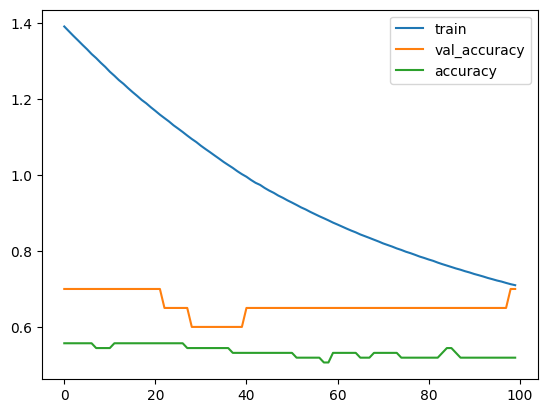

In [20]:
plt.plot(history.history['loss'],label=['train'])
plt.plot(history.history['val_accuracy'],label=['val_accuracy'])
plt.plot(history.history['accuracy'],label=['accuracy'])
plt.legend()

In [21]:
model2 = Sequential()
initializer = tf.keras.initializers.RandomNormal(mean=0.,stddev=1.)
model2.add(Dense(10,input_dim=2,activation="tanh",kernel_initializer=initializer))
model2.add(Dense(1,activation="sigmoid",kernel_initializer=initializer))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
model2.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [24]:
history = model2.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8101 - loss: 0.4178 - val_accuracy: 0.8500 - val_loss: 0.2480
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8101 - loss: 0.4171 - val_accuracy: 0.8500 - val_loss: 0.2477
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8101 - loss: 0.4164 - val_accuracy: 0.8500 - val_loss: 0.2474
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8101 - loss: 0.4157 - val_accuracy: 0.8500 - val_loss: 0.2471
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8101 - loss: 0.4149 - val_accuracy: 0.8500 - val_loss: 0.2469
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8101 - loss: 0.4141 - val_accuracy: 0.8500 - val_loss: 0.2466
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8101 - loss: 0.4135 - val_accuracy: 0.8500 - val_loss: 0.2464
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8101 - loss: 0.4128 - val_accuracy: 0.8500 - val_loss:

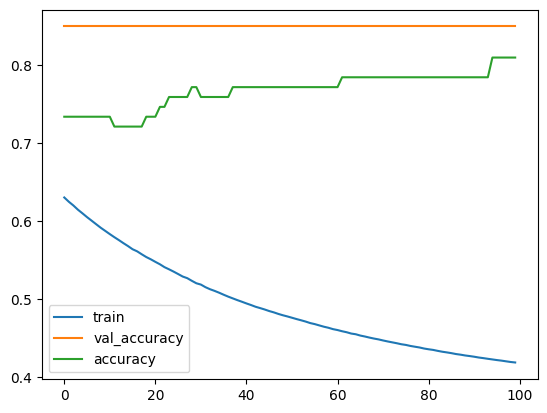

In [26]:
plt.plot(history.history['loss'],label=['train'])
plt.plot(history.history['val_accuracy'],label=['val_accuracy'])
plt.plot(history.history['accuracy'],label=['accuracy'])
plt.legend()

In [28]:
X = X.to_numpy()
y = y.to_numpy()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

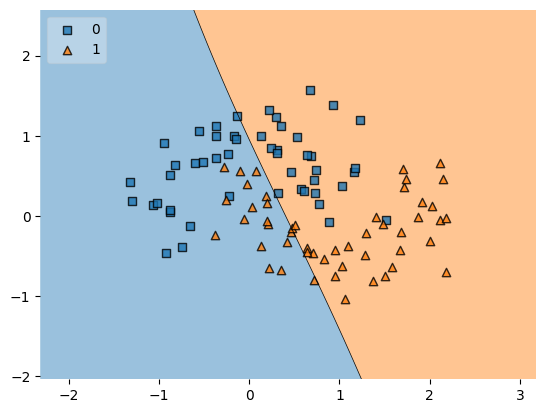

In [29]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

#when we took tanh plus random uniform

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

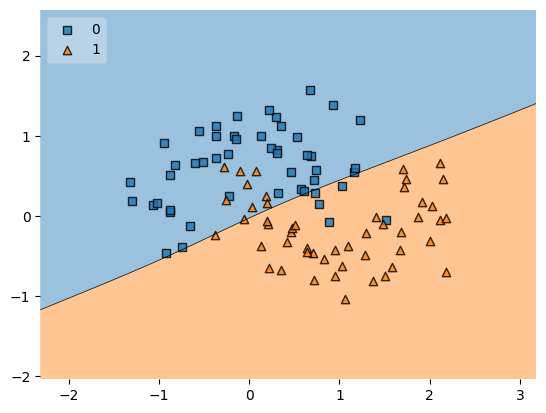

In [30]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model2, legend=2)

#when we use tanh with random normal

In [31]:
model3 = Sequential()
initializer = tf.keras.initializers.RandomNormal(mean=0.,stddev=1.)
model3.add(Dense(10,input_dim=2,activation="relu",kernel_initializer=initializer))
model3.add(Dense(1,activation="sigmoid",kernel_initializer=initializer))

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model3.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [33]:
history = model3.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.5949 - loss: 0.8366 - val_accuracy: 0.7500 - val_loss: 0.6103
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5949 - loss: 0.8292 - val_accuracy: 0.7500 - val_loss: 0.6053
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5949 - loss: 0.8222 - val_accuracy: 0.7500 - val_loss: 0.6003
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5949 - loss: 0.8154 - val_accuracy: 0.7500 - val_loss: 0.5953
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5949 - loss: 0.8085 - val_accuracy: 0.7500 - val_loss: 0.5904
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5949 - loss: 0.8014 - val_accuracy: 0.7500 - val_loss: 0.5856
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5949 - loss: 0.7949 - val_accuracy: 0.7500 - val_loss: 0.5809
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5949 - loss: 0.7877 - val_accuracy: 0.7500 - val_loss

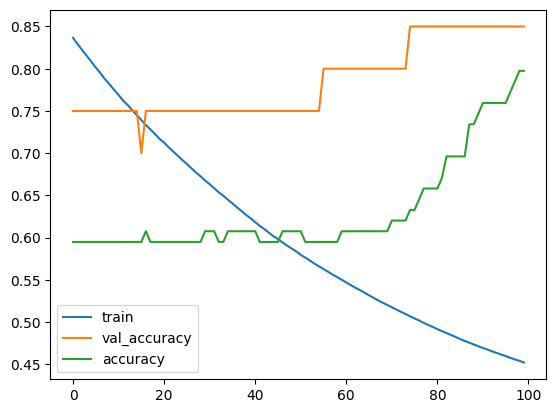

In [34]:
plt.plot(history.history['loss'],label=['train'])
plt.plot(history.history['val_accuracy'],label=['val_accuracy'])
plt.plot(history.history['accuracy'],label=['accuracy'])
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

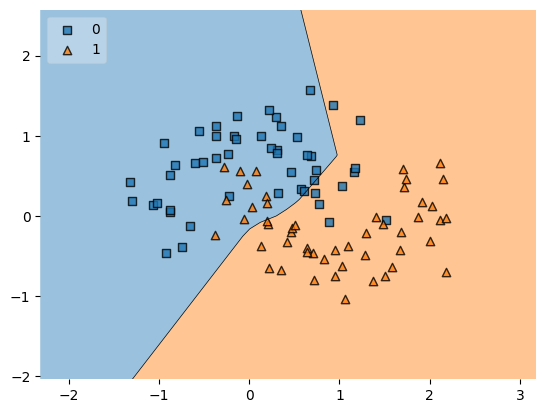

In [35]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model3, legend=2)

#when we use relu with random normal

In [37]:
model4 = Sequential()
initializer = tf.keras.initializers.RandomUniform(minval=0.,maxval=1.)
model4.add(Dense(10,input_dim=2,activation="relu",kernel_initializer=initializer))
model4.add(Dense(1,activation="sigmoid",kernel_initializer=initializer))

model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
model4.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [40]:
history = model4.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.5316 - loss: 1.1933 - val_accuracy: 0.5500 - val_loss: 0.8958
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5570 - loss: 1.1816 - val_accuracy: 0.6000 - val_loss: 0.8883
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5443 - loss: 1.1685 - val_accuracy: 0.5500 - val_loss: 0.8811
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5443 - loss: 1.1562 - val_accuracy: 0.5500 - val_loss: 0.8740
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5443 - loss: 1.1447 - val_accuracy: 0.5500 - val_loss: 0.8669
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5443 - loss: 1.1323 - val_accuracy: 0.5500 - val_loss: 0.8599
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5443 - loss: 1.1209 - val_accuracy: 0.5500 - val_loss: 0.8531
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5443 - loss: 1.1095 - val_accuracy: 0.5500 - val_loss

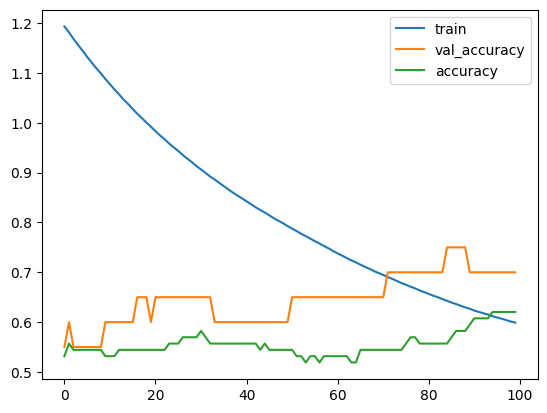

In [41]:
plt.plot(history.history['loss'],label=['train'])
plt.plot(history.history['val_accuracy'],label=['val_accuracy'])
plt.plot(history.history['accuracy'],label=['accuracy'])
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

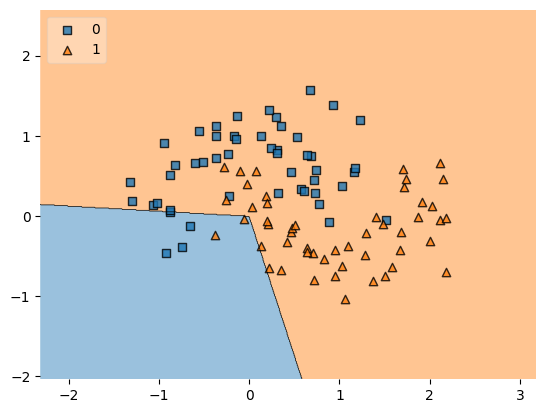

In [42]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model3, legend=2)

#when we use relu with random uniform